In [33]:
# Importing libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

import warnings
warnings.filterwarnings("ignore")

In [34]:
# load Data
df_zomato = pd.read_csv("/content/Zomato-data-.csv")
df_zomato.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [35]:
df_zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [36]:
df_zomato.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


**Data Cleaning and Preprocessing**

In [37]:
#Remove duplicates
df_zomato.duplicated().sum()
df_zomato.drop_duplicates(inplace=True)

In [43]:
# Clean Rating
df_zomato['rate'] = df_zomato['rate'].str.replace('/5', '', regex=False)
df_zomato['rate'] = pd.to_numeric(df_zomato['rate'], errors='coerce')
df_zomato['rate'].fillna(df_zomato['rate'].mean(), inplace=True)

# Popularity Score
df_zomato['Popularity_Score'] = df_zomato['rate'] * np.log1p(df_zomato['votes'])

# Value Score
df_zomato['Value_Score'] = df_zomato['rate'] / df_zomato['approx_cost(for two people)']

AttributeError: Can only use .str accessor with string values!

In [44]:
#Handle Missing Values
# Numerical
num_cols = df_zomato.select_dtypes(include=np.number).columns
for col in num_cols:
    df_zomato[col].fillna(df_zomato[col].median(), inplace=True)

# Categorical
cat_cols = df_zomato.select_dtypes(include='object').columns
for col in cat_cols:
    df_zomato[col].fillna(df_zomato[col].mode()[0], inplace=True)

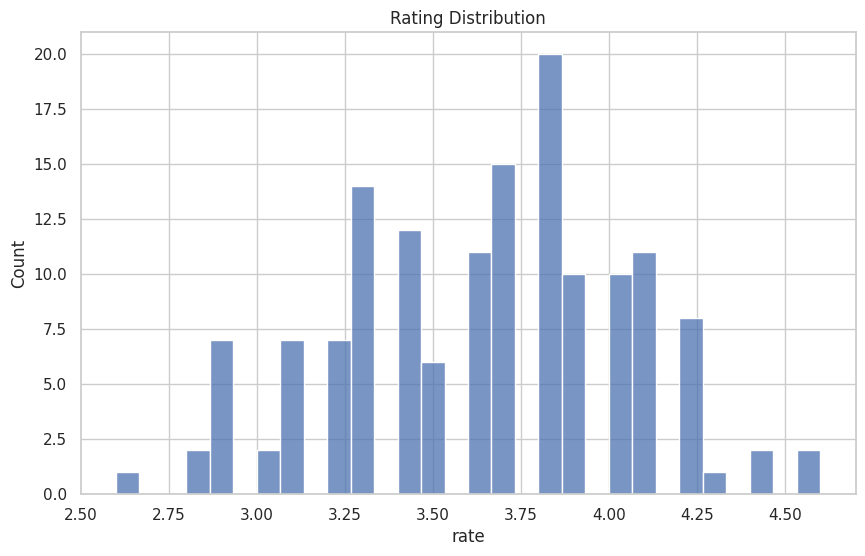

In [45]:
#Rating Distribution
sns.histplot(df_zomato['rate'], bins=30)
plt.title("Rating Distribution")
plt.show()

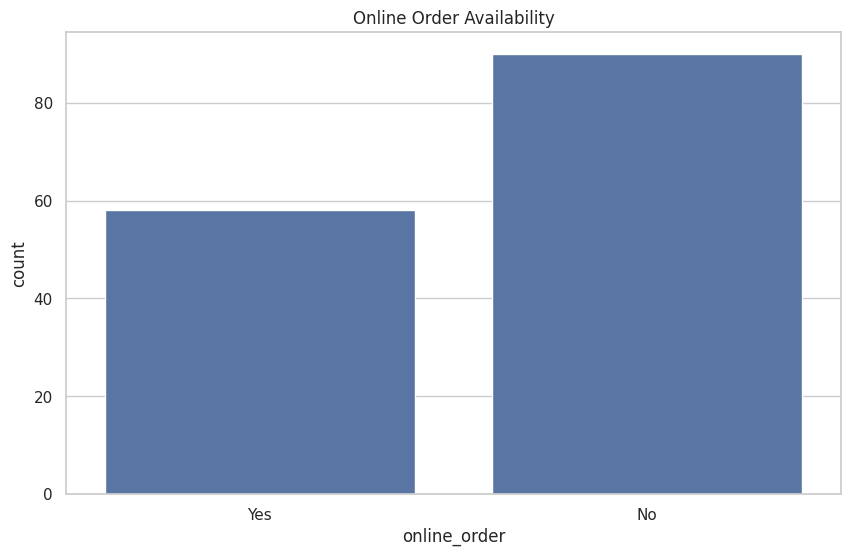

In [46]:
#Online Order Availability
sns.countplot(x='online_order', data=df_zomato)
plt.title("Online Order Availability")
plt.show()

In [47]:
df_zomato['rate'] = df_zomato['rate'].str.replace('/5', '', regex=False)
df_zomato['rate'] = pd.to_numeric(df_zomato['rate'], errors='coerce')
df_zomato['rate'].fillna(df_zomato['rate'].mean(), inplace=True)

#Cost vs Rating
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df_zomato)
plt.title("Cost vs Rating")
plt.xlabel("Approximate Cost (for two people)")
plt.ylabel("Rate")
plt.show()

AttributeError: Can only use .str accessor with string values!

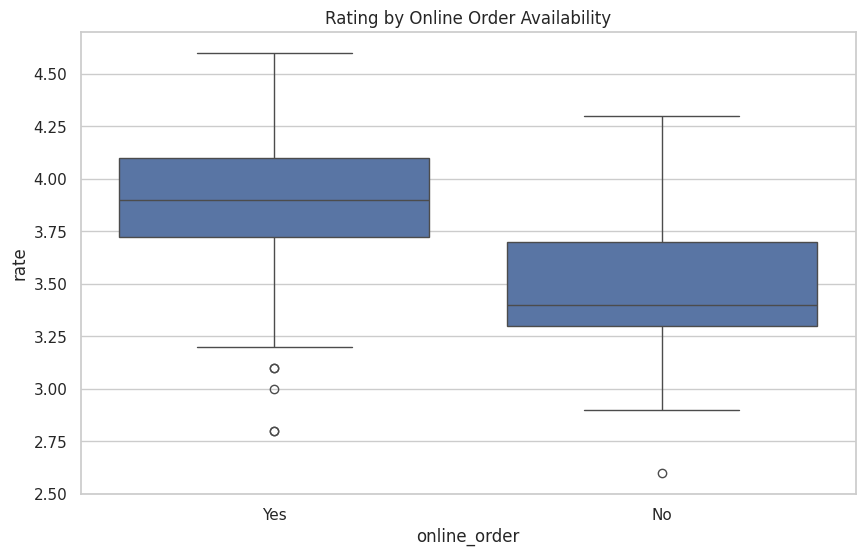

In [48]:
#Online Order vs Rating
sns.boxplot(x='online_order', y='rate', data=df_zomato)
plt.title("Rating by Online Order Availability")
plt.show()

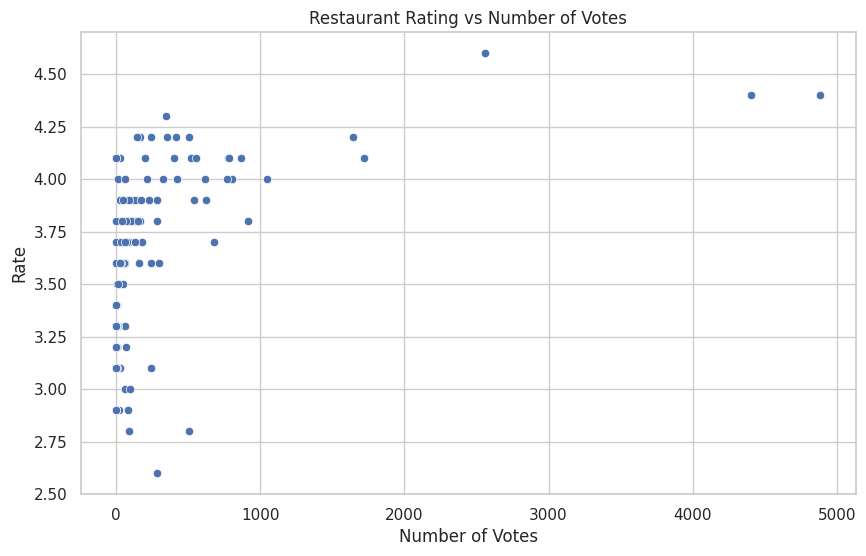

In [49]:
# Scatter plot for Rate vs Votes (strongest positive correlation)
plt.figure(figsize=(10,6))
sns.scatterplot(x='votes', y='rate', data=df_zomato)
plt.title("Restaurant Rating vs Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Rate")
plt.show()

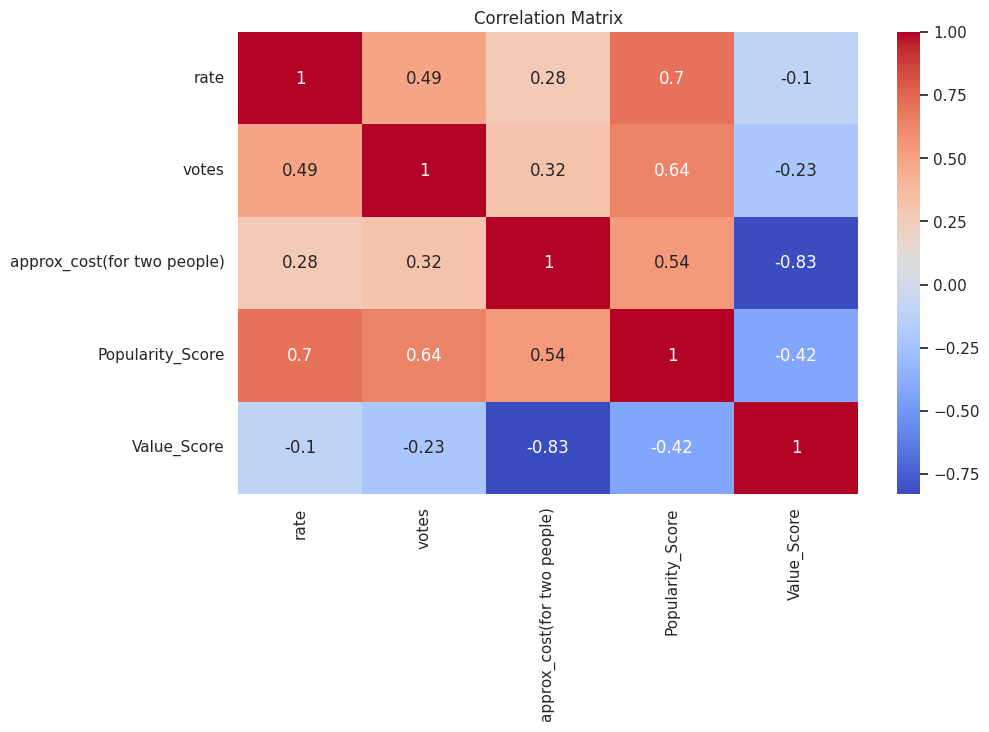

In [50]:
#Correlation Heatmap
numeric_df = df_zomato.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



In [51]:
#Top Rated Restaurants
top_restaurants = df_zomato.sort_values(by='rate', ascending=False).head(10)
print(top_restaurants[['name', 'rate', 'approx_cost(for two people)']])

                      name  rate  approx_cost(for two people)
7                   Onesta   4.6                          600
44                  Onesta   4.6                          600
38       Empire Restaurant   4.4                          750
86           Meghana Foods   4.4                          600
52  Corner House Ice Cream   4.3                          400
57                  Wamama   4.2                          800
60           Peppy Peppers   4.2                          800
81           Frozen Bottle   4.2                          400
34                  Faasos   4.2                          500
12        The Coffee Shack   4.2                          500


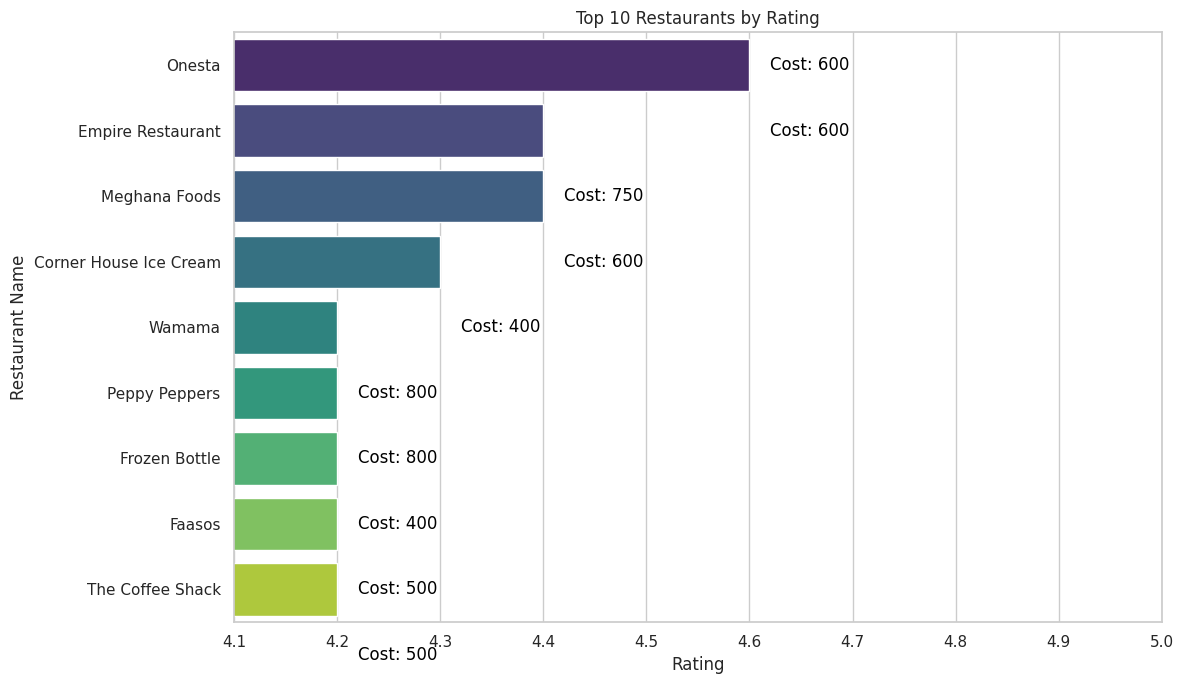

In [52]:
# Visualize Top Rated Restaurants
plt.figure(figsize=(12, 7))
sns.barplot(x='rate', y='name', data=top_restaurants_cleaned, palette='viridis')
plt.title('Top 10 Restaurants by Rating')
plt.xlabel('Rating')
plt.ylabel('Restaurant Name')
plt.xlim(top_restaurants_cleaned['rate'].min() - 0.1, 5.0) # Set x-axis limit for better visualization of ratings

# Adding approximate cost labels to the bars
for index, row in top_restaurants_cleaned.iterrows():
    plt.text(row['rate'] + 0.02, top_restaurants_cleaned.index.get_loc(index), f"Cost: {row['approx_cost(for two people)']}", color='black', ha="left", va="center")

plt.tight_layout()
plt.show()

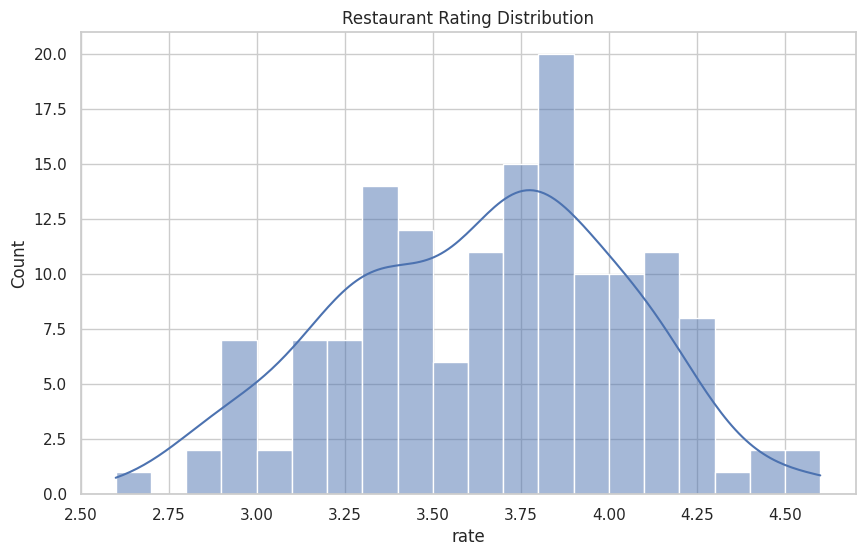

In [53]:
#Rating Distribution
sns.histplot(df_zomato['rate'], bins=20, kde=True)
plt.title("Restaurant Rating Distribution")
plt.show()


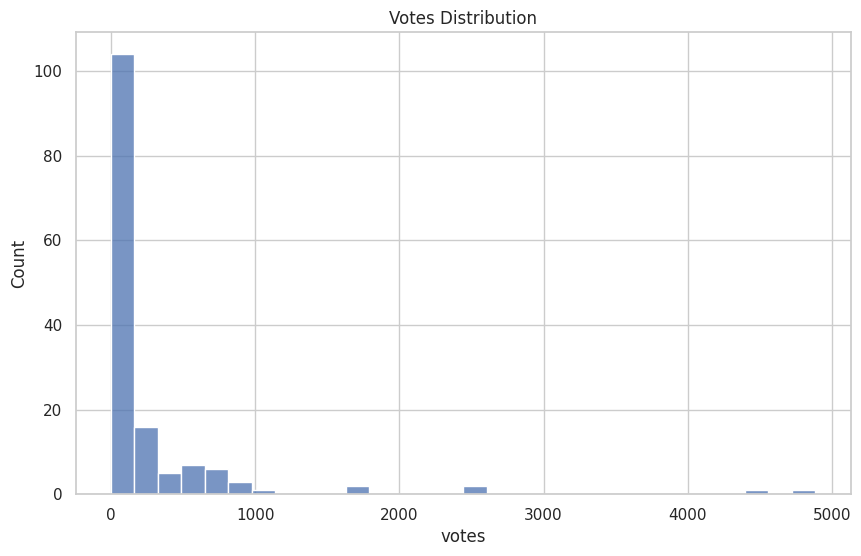

In [54]:
#Votes Distribution
sns.histplot(df_zomato['votes'], bins=30)
plt.title("Votes Distribution")
plt.show()

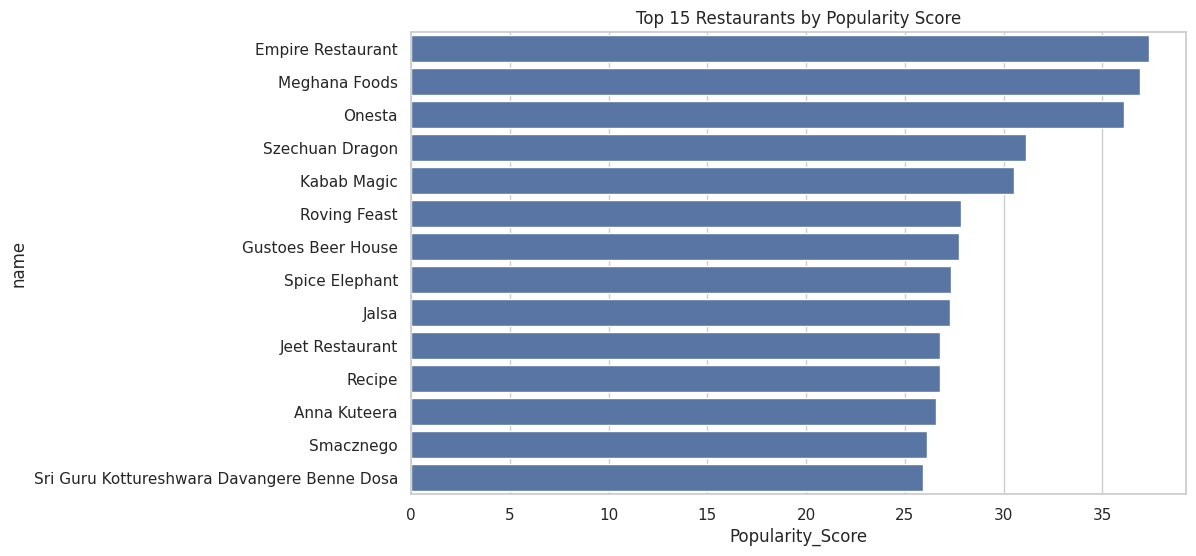

In [55]:
#Popularity Score Ranking
top_popular = df_zomato.sort_values('Popularity_Score', ascending=False).head(15)

sns.barplot(x='Popularity_Score', y='name', data=top_popular)
plt.title("Top 15 Restaurants by Popularity Score")
plt.show()

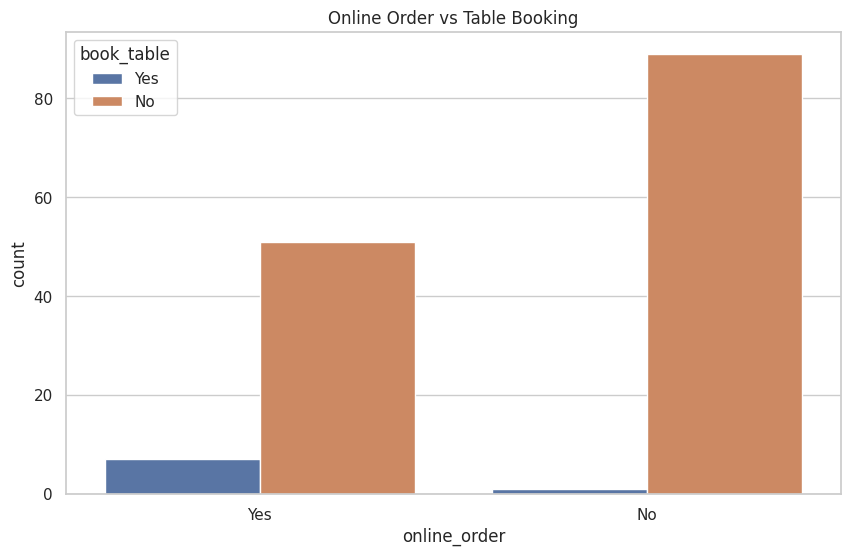

In [56]:
#Online Order & Table Booking Interaction
sns.countplot(x='online_order', hue='book_table', data=df_zomato)
plt.title("Online Order vs Table Booking")
plt.show()

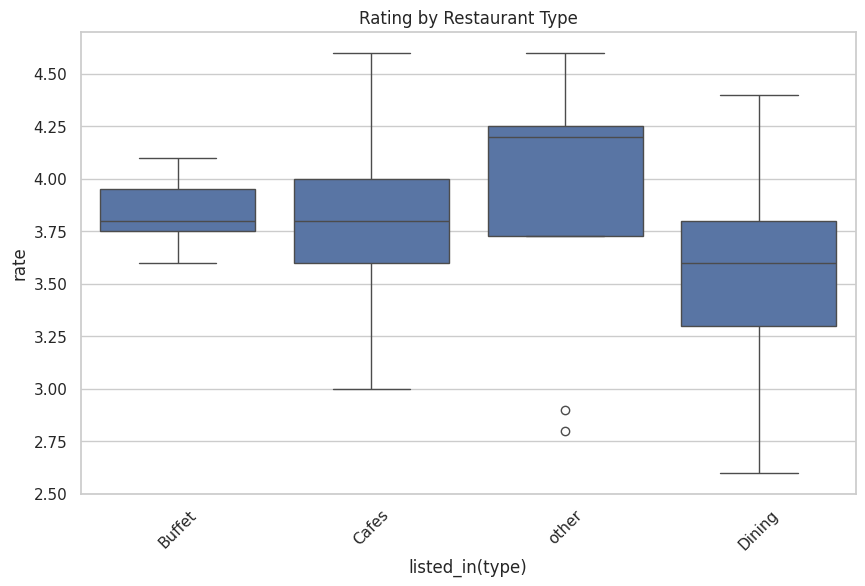

In [57]:
#Rating by Restaurant Type
sns.boxplot(x='listed_in(type)', y='rate', data=df_zomato)
plt.title("Rating by Restaurant Type")
plt.xticks(rotation=45)
plt.show()

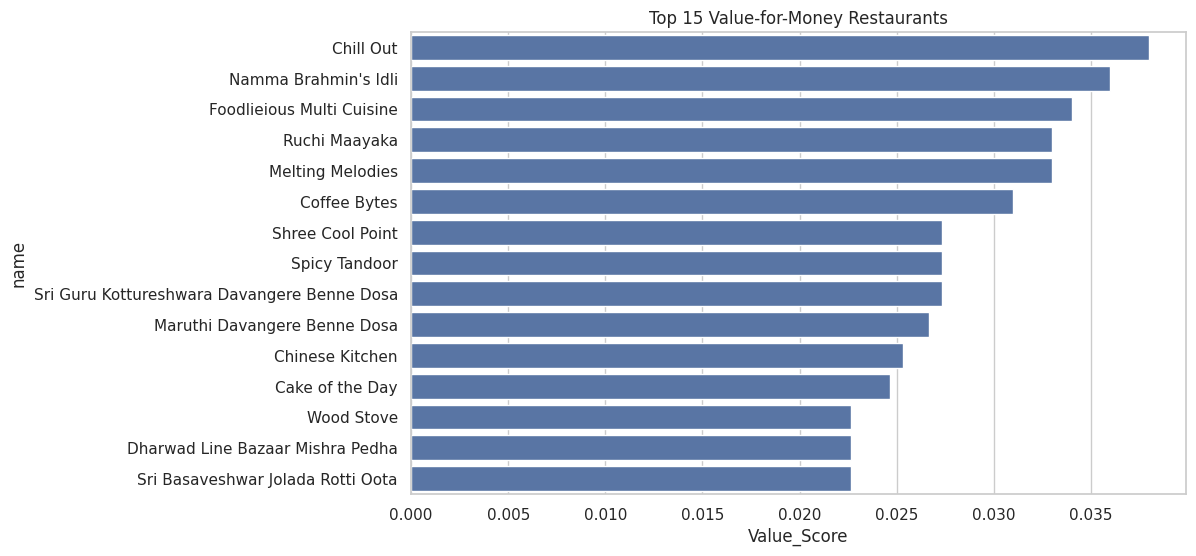

In [58]:
#Value for Money Visualization
top_value = df_zomato.sort_values('Value_Score', ascending=False).head(15)

sns.barplot(x='Value_Score', y='name', data=top_value)
plt.title("Top 15 Value-for-Money Restaurants")
plt.show()

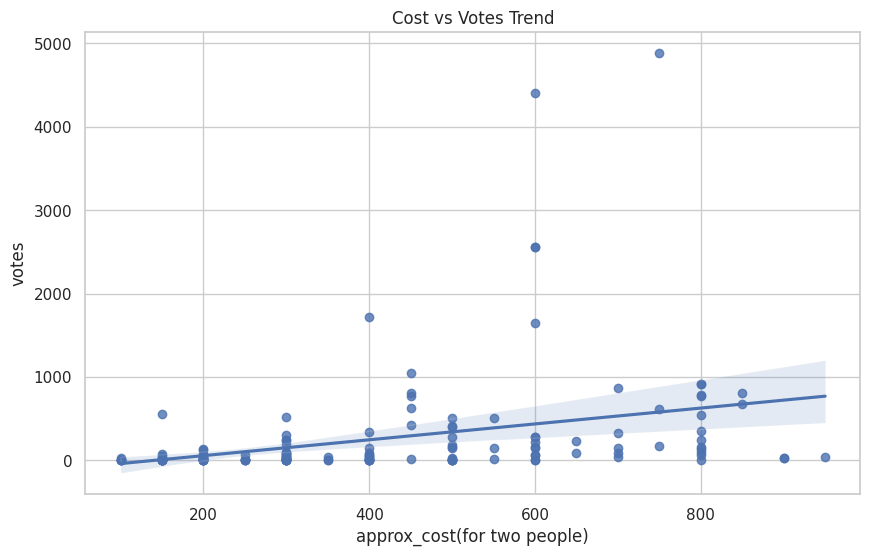

In [59]:
#Votes vs Cost Trend
sns.regplot(x='approx_cost(for two people)', y='votes', data=df_zomato)
plt.title("Cost vs Votes Trend")
plt.show()

**Recommendations**


1️-Promote High Popularity Score Restaurants

Use popularity score (rating × log(votes)) to highlight impactful restaurants.
→ Feature them in marketing campaigns.

2️-Encourage Dual Service Model

Restaurants offering both online ordering and table booking show stronger engagement.
→ Incentivize restaurants to enable both services.

3️-Optimize Value-for-Money Positioning

High value-score restaurants (rating / cost) attract strong customer satisfaction.
→ Promote affordable high-rated restaurants.

4️- Address Overpriced Low-Rating Restaurants

High cost + low rating indicates poor perceived value.
→ Recommend pricing adjustments or service improvements.

5️-Segment Strategy by Restaurant Type

Different dining types show different rating and vote behavior.
→ Customize marketing and pricing strategies by category (casual vs fine dining).